In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.stock_screener import fetch_screener_data

sns.set_theme(style="darkgrid")
stock_pool = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "TSLA"]
raw_data = fetch_screener_data(stock_pool)

raw_data["Close"].head()

/Users/jasonshi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Fetching historical data for companies: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'TSLA']...


[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA,TSLA
Date,,,,,,
2026-04-15,266.184753,248.500000,337.119995,410.331268,198.869995,391.950012
2026-04-16,263.157532,249.699997,336.019989,419.351746,198.350006,388.899994
2026-04-17,269.981262,250.559998,341.679993,421.876282,201.679993,400.619995
2026-04-20,272.798645,248.279999,337.420013,417.166473,202.059998,392.500000
2026-04-21,265.925018,249.910004,332.290009,423.243317,199.880005,386.420013


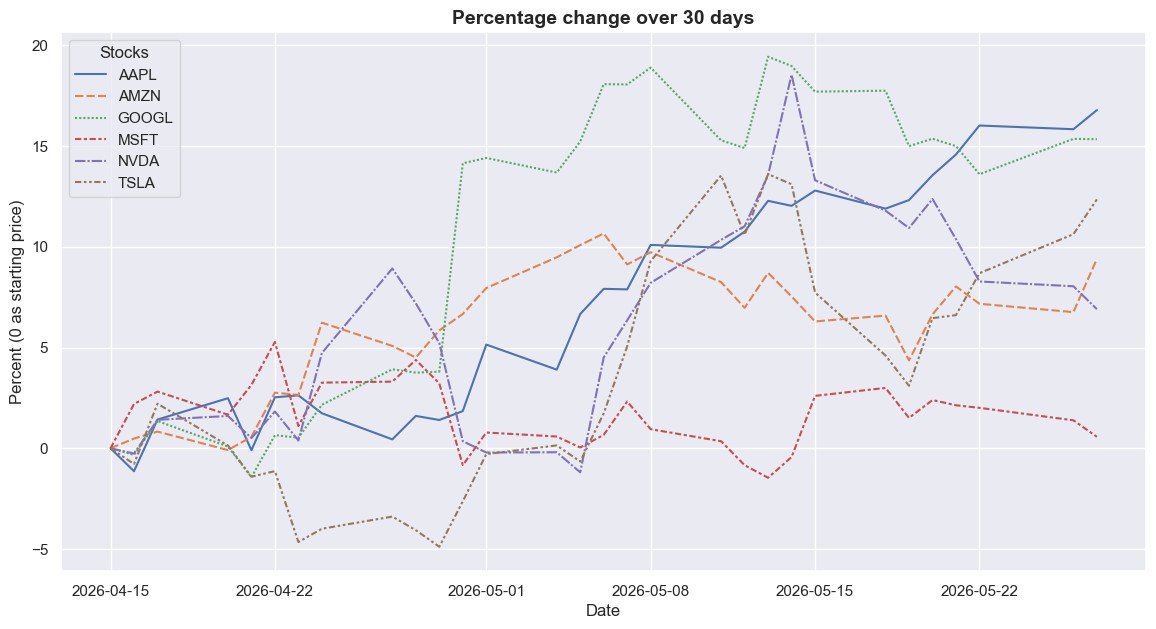

In [2]:
close_prices = raw_data["Close"]
pct_close = (close_prices - close_prices.iloc[0]) / close_prices.iloc[0] * 100

plt.figure(figsize=(14,7))
sns.lineplot(data=pct_close)

plt.title("Percentage change over 30 days", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Percent (0 as starting price)", fontsize=12)
plt.legend(title="Stocks")
plt.show()

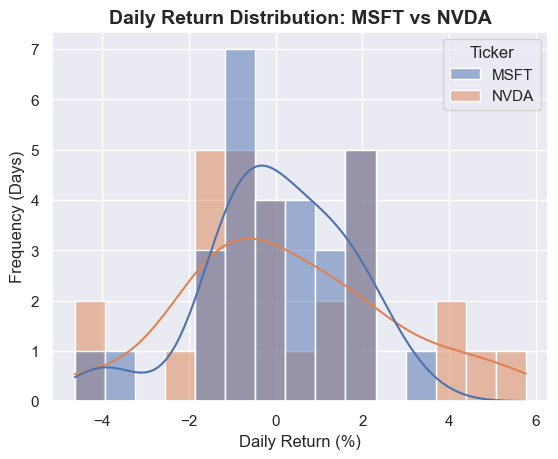

In [3]:
daily_returns = close_prices.pct_change() * 100
sns.histplot(data=daily_returns[["MSFT", "NVDA"]], kde=True, bins=15, alpha=0.5)

plt.title("Daily Return Distribution: MSFT vs NVDA", fontsize=14, fontweight='bold')
plt.xlabel("Daily Return (%)", fontsize=12)
plt.ylabel("Frequency (Days)", fontsize=12)

plt.show()

In [4]:
from src.indicators import calculate_sma

close_prices = raw_data["Close"]

sma_5 = calculate_sma(close_prices, window=5)
sma_20 = calculate_sma(close_prices, window=20)

print("Raw Prices vs 5-Day SMA for MSFT:")
print(pd.concat([close_prices["MSFT"], sma_5["MSFT"]], axis=1, keys=["Raw Close", "5-Day SMA"]).tail(10))

Raw Prices vs 5-Day SMA for MSFT:
             Raw Close   5-Day SMA
Date                              
2026-05-13  404.334259  411.414917
2026-05-14  408.545135  409.151819
2026-05-15  421.008148  410.508881
2026-05-18  422.624664  412.680182
2026-05-19  416.517883  414.606018
2026-05-20  420.149994  417.769165
2026-05-21  419.089996  419.878137
2026-05-22  418.570007  419.390509
2026-05-26  416.029999  418.071576
2026-05-27  412.670013  417.302002


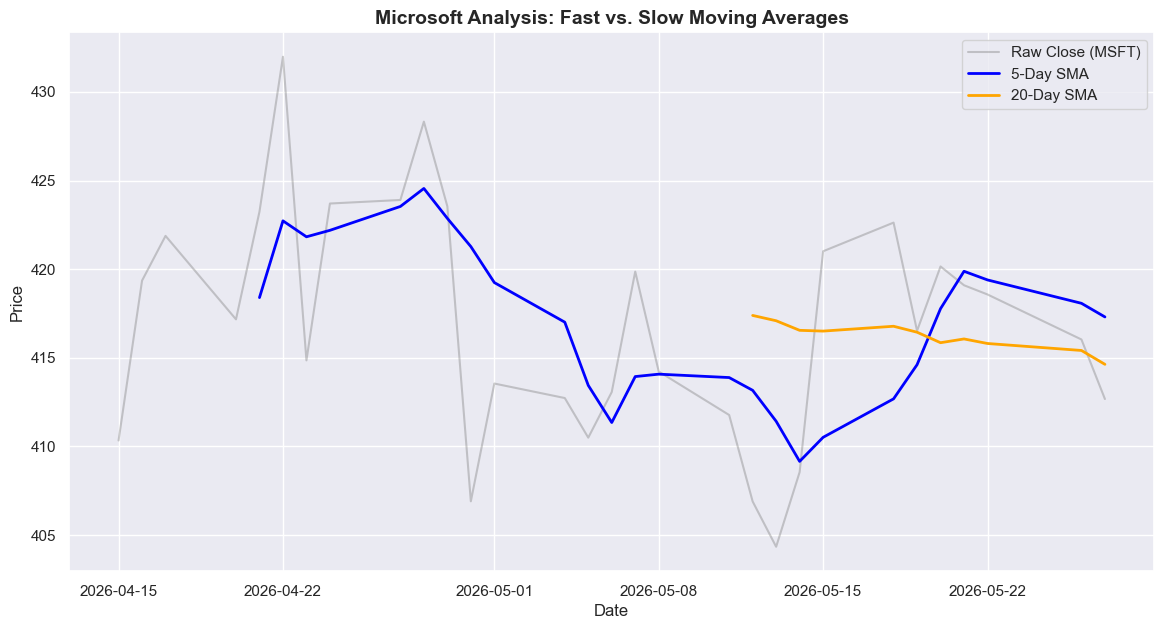

In [5]:
plt.figure(figsize=(14, 7))

sns.lineplot(data=close_prices["MSFT"], label="Raw Close (MSFT)", color="gray", alpha=0.4)
sns.lineplot(data=sma_5["MSFT"], label="5-Day SMA", color="blue", linewidth=2)
sns.lineplot(data=sma_20["MSFT"], label="20-Day SMA", color="orange", linewidth=2)

plt.title("Microsoft Analysis: Fast vs. Slow Moving Averages", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend()

plt.show()

In [6]:
from src.indicators import calculate_sma, detect_golden_cross

sma_5 = calculate_sma(close_prices, window=5)
sma_20 = calculate_sma(close_prices, window=20)

crossed_stocks = detect_golden_cross(sma_5, sma_20)

print("Automated Golden Cross Detection:")
print(f"Stocks showing a golden cross today: {crossed_stocks}")

Automated Golden Cross Detection:
Stocks showing a golden cross today: ['AAPL', 'MSFT', 'NVDA', 'TSLA']


In [7]:
from src.indicators import calculate_rsi

rsi_df = calculate_rsi(close_prices, window=14)
latest_rsi = rsi_df.iloc[-1]

print("Today's RSI indices:")
for ticker, rsi_val in latest_rsi.items():
    status = "Normal"
    if rsi_val > 70:
        status = "High Risk"
    elif rsi_val < 30:
        status = "Cheap"
    
    print(f"{ticker}: {rsi_val:.2f} -> {status}")

Today's RSI indices:
AAPL: 71.01 -> High Risk
AMZN: 62.31 -> Normal
GOOGL: 57.67 -> Normal
MSFT: 58.47 -> Normal
NVDA: 48.24 -> Normal
TSLA: 60.95 -> Normal


In [ ]:
buy_stocks = []
skip_stocks = []

print("Screener Conclusions:")

for ticker in crossed_stocks:
    rsi_val = latest_rsi[ticker]
    
    # Filter out anything overbought
    if rsi_val > 70:
        print(f"Skip {ticker}: Strong trend, but RSI ({rsi_val:.1f}) > 70.")
        skip_stocks.append(ticker)
    else:
        print(f"Buy {ticker}: Strong trend and RSI ({rsi_val:.1f}) < 30.")
        buy_stocks.append(ticker)

print(f"Final stock selections: {buy_stocks}")

Screener Conclusions:
Skip AAPL: Strong trend, but RSI (71.0) > 70.
Buy MSFT: Strong trend and RSI (58.5) < 70.
Buy NVDA: Strong trend and RSI (48.2) < 70.
Buy TSLA: Strong trend and RSI (61.0) < 70.
Final stock selections: ['MSFT', 'NVDA', 'TSLA']
